In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import tensorflow as tf
print("Using:", tf.config.list_physical_devices())

I0000 00:00:1773849480.576614    3273 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Using: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


E0000 00:00:1773849482.429321    3273 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [ ]:
# import tensorflow as tf
# print(tf.config.list_physical_devices('GPU'))

In [2]:
pip install tensorflow opencv-python matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# #Avoid OOM(out of memory) by setting GPU memory Consumption Growth
# import tensorflow as tf
# gpus = tf.config.list_physical_devices('GPU')
# for gpu in gpus:
#     tf.config.experimental.set_memory_growth(gpu, True)

In [3]:
##Remove unwanted file formats
import cv2
import os
import tensorflow as tf
import imghdr
from matplotlib import pyplot as plt

/tmp/ipykernel_3273/3374848762.py:5: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [4]:
data_dir = "data"

In [5]:
file_formats = ["jpeg","jpg","bmp","png"]

In [6]:
data_folders = os.listdir(data_dir)
for image_class in data_folders:
    for image in os.listdir(os.path.join(data_dir,image_class)):
        image_path = os.path.join(data_dir,image_class,image)
        try:
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in file_formats:
                os.remove(image_path)
                print("Image not in ext list {}".format(image_path))
        except Exception as e:
            print("Issue with {}".format(image_path))

In [7]:
import numpy as np 

In [24]:
data = tf.keras.utils.image_dataset_from_directory("data")

Found 569 files belonging to 5 classes.


In [25]:
data_iterator = data.as_numpy_iterator()

In [26]:
batch = data_iterator.next()

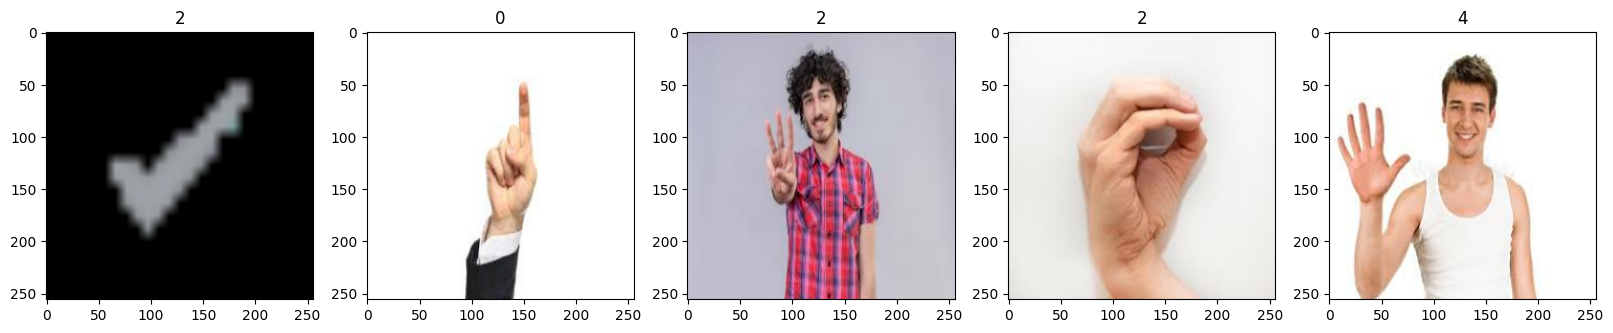

In [27]:
###visual data to see which batch belongs to which folder
#creates 4 image slots side by side
fig, ax = plt.subplots(ncols=5,figsize=(20,20))
for idx,img in enumerate(batch[0][:5]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [28]:
data = data.map(lambda x,y:(x/255,y))

In [29]:
scaled_ite = data.as_numpy_iterator()
batch = scaled_ite.next()
batch[0].min()

np.float32(0.0)

In [30]:
len(data)

18

In [31]:
train_size = int(len(data) * 0.7)
val_size = int(len(data) * 0.2)+1
test_size = int(len(data) * 0.1)+1

train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [33]:
model = Sequential()

model.add(Conv2D(16, (3,3), 1, activation="relu", input_shape=(256,256,3)))
model.add(MaxPooling2D())

model.add(Conv2D(32, (3,3), 1, activation="relu"))
model.add(MaxPooling2D())

model.add(Conv2D(16, (3,3), 1, activation="relu"))

model.add(Flatten())

model.add(Dense(256, activation="relu"))
model.add(Dense(5, activation="softmax"))

In [34]:
model.compile("adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [35]:
pip install tensorboard

Note: you may need to restart the kernel to use updated packages.


In [36]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    14,745,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,756,853 (56.29 MB)

 Trainable params: 14,756,853 (56.29 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
log_directory = "logs"
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_directory)
hist = model.fit(train,epochs=20,validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 671ms/step - accuracy: 0.2448 - loss: 3.8387 - val_accuracy: 0.4453 - val_loss: 1.5983
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 608ms/step - accuracy: 0.3776 - loss: 1.6314 - val_accuracy: 0.3359 - val_loss: 1.5449
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 607ms/step - accuracy: 0.4583 - loss: 1.5540 - val_accuracy: 0.3828 - val_loss: 1.5363
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 616ms/step - accuracy: 0.3802 - loss: 1.4850 - val_accuracy: 0.5312 - val_loss: 1.2841
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 592ms/step - accuracy: 0.5130 - loss: 1.3039 - val_accuracy: 0.4688 - val_loss: 1.2717
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 614ms/step - accuracy: 0.5651 - loss: 1.2145 - val_accuracy: 0.5625 - val_loss: 1.2422
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 607ms/step - accuracy: 0.5807 - loss: 1.0908 - val_accuracy: 0.6797 - val_loss: 0.8993
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 616ms/step - accuracy: 0.7370 - loss: 0.7352 - val_accuracy: 0.

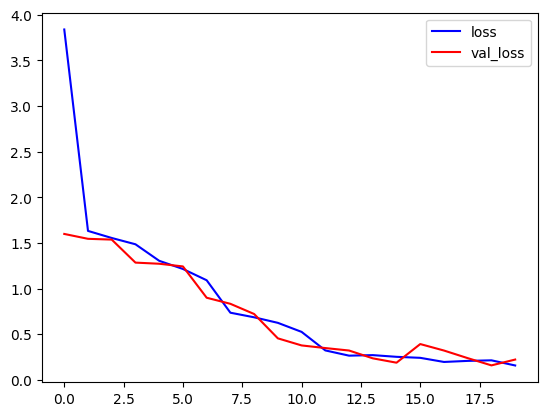

In [38]:
#Plot performance 
fig = plt.figure()
plt.plot(hist.history["loss"],color="blue",label="loss")
plt.plot(hist.history["val_loss"],color="red", label="val_loss")
plt.legend(loc="upper right")
plt.show()

In [42]:
from tensorflow.keras.metrics import CategoricalAccuracy, Precision, Recall

In [43]:
pre = Precision()
re = Recall()
acc = CategoricalAccuracy()

for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    
    y_onehot = tf.one_hot(y.astype(int), 5)
    
    pre.update_state(y_onehot, yhat)
    re.update_state(y_onehot, yhat)
    acc.update_state(y_onehot, yhat)

print(f"Precision: {pre.result().numpy()}")
print(f"Recall: {re.result().numpy()}")
print(f"Accuracy: {acc.result().numpy()}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
Precision: 0.9824561476707458
Recall: 0.9824561476707458
Accuracy: 0.9824561476707458


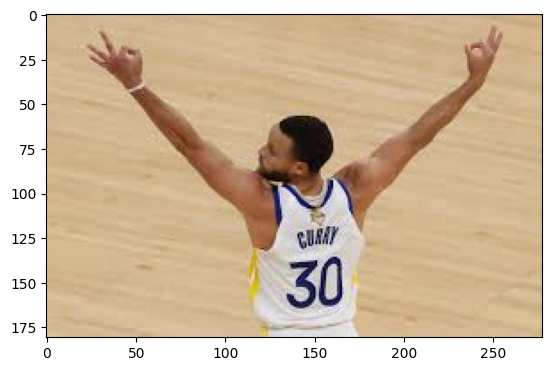

In [55]:
img = cv2.imread("steph_holdin3.jpg")
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.show()

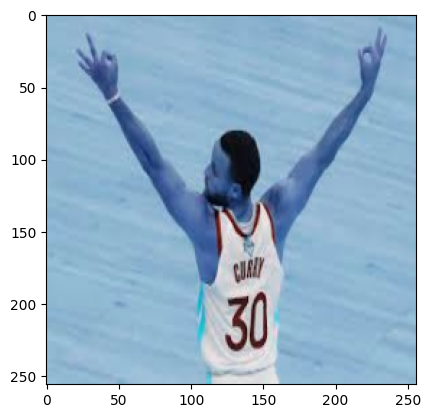

In [56]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [59]:
yhat = model.predict(np.expand_dims(resize/255,0))
print(yhat)
print(f"Predicted class: {np.argmax(yhat)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
[[0.33593118 0.06790685 0.58475924 0.00557874 0.00582404]]
Predicted class: 2


In [66]:
from tensorflow.keras.models import load_model
model.save(os.path.join("models","howmanyfingersmodel.h5"))

In [67]:
load_model = load_model(os.path.join("models","howmanyfingersmodel.h5"))

In [70]:
yhat_new = load_model.predict(np.expand_dims(resize/255,0))
yhat_new

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


array([[0.33593118, 0.06790685, 0.58475924, 0.00557874, 0.00582404]],
      dtype=float32)